In [1]:
import os
import pandas as pd

# Carichiamo la tabella dei film
films = pd.read_csv("../data/processed/film_with_trailers.csv")

# Lista dei trailer davvero scaricati (i file .mp4)
cartella = "../data/raw/trailers"
files = os.listdir(cartella)

trailer_scaricati = []
for f in files:
    if f.endswith(".mp4"):
        trailer_scaricati.append(f)

print("Trailer scaricati:", len(trailer_scaricati))

Trailer scaricati: 133


In [2]:
import sys
sys.path.append("..")   # dice a Python di guardare anche nella cartella sopra

from src.frames import extract_frames
from src.metrics import curve_from_frames

# Prendiamo un trailer qualsiasi per la prova
primo_file = trailer_scaricati[0]
percorso = "../data/raw/trailers/" + primo_file
print("Provo con:", primo_file)

# Estraiamo i frame (uno al secondo)
frames = extract_frames(percorso, per_second=1)
print("Frame estratti:", len(frames))

# Calcoliamo le curve di colore
brightness, temperature, colours = curve_from_frames(frames)
print("Misure di brightness:", len(brightness))
print("Prima misura brightness:", brightness[0])
print("Prima misura temperature:", temperature[0])

Provo con: tt0381061.mp4
Frame estratti: 155


ValueError: too many values to unpack (expected 3)

In [ ]:
import time

# Qui salviamo una riga per film
risultati = []

# Contatore per vedere l'avanzamento
fatti = 0

for nome_file in trailer_scaricati:
    tconst = nome_file.replace(".mp4", "")
    percorso = "../data/raw/trailers/" + nome_file

    # Estraiamo frame e curve
    frames = extract_frames(percorso, per_second=1)
    brightness, temperature, colours = curve_from_frames(frames)

    # Calcoliamo i valori riassuntivi (usando pandas per media e deviazione)
    import numpy as np
    riga = {
        "tconst": tconst,
        "brightness_media": np.mean(brightness),
        "brightness_std": np.std(brightness),
        "temperature_media": np.mean(temperature),
        "temperature_std": np.std(temperature),
        "n_frames": len(frames),
    }
    risultati.append(riga)

    fatti = fatti + 1
    if fatti % 20 == 0:
        print("Elaborati", fatti, "trailer...")

print("Finito! Trailer elaborati:", len(risultati))

Elaborati 20 trailer...
Elaborati 40 trailer...
Elaborati 60 trailer...
Elaborati 80 trailer...
Elaborati 100 trailer...
Elaborati 120 trailer...
Finito! Trailer elaborati: 133


In [ ]:
# Trasformiamo la lista di risultati in una tabella
colori_df = pd.DataFrame(risultati)

# Uniamo il genere (e il titolo) prendendoli dalla tabella films
colonne_utili = films[["tconst", "primaryTitle", "genere_principale", "startYear"]]
colori_df = colori_df.merge(colonne_utili, on="tconst")

print("Righe:", len(colori_df))
colori_df.head()

Righe: 133


,tconst,brightness_media,brightness_std,temperature_media,temperature_std,n_frames,primaryTitle,genere_principale,startYear
0,tt0381061,21.096695,10.851015,1.919440,6.490429,155,Casino Royale,Action,2006
1,tt0074285,19.384924,12.648849,6.694335,11.761136,127,Carrie,Horror,1976
2,tt0948470,11.445924,8.660381,-0.823597,8.654259,162,The Amazing Spider-Man,Action,2012
3,tt1631867,17.591673,11.684464,4.139038,6.736695,157,Edge of Tomorrow,Action,2014
4,tt0375679,18.845243,14.084286,3.997681,4.674487,148,Crash,Crime,2004


In [ ]:
# Luminanza media per genere
media_per_genere = colori_df.groupby("genere_principale")["brightness_media"].mean()
print("Luminanza media per genere (piu bassa = piu scuro):")
print(media_per_genere.sort_values())

Luminanza media per genere (piu bassa = piu scuro):
genere_principale
Horror    12.327302
Crime     18.924284
Action    19.405211
Drama     20.400572
Comedy    23.622460
Name: brightness_media, dtype: float64


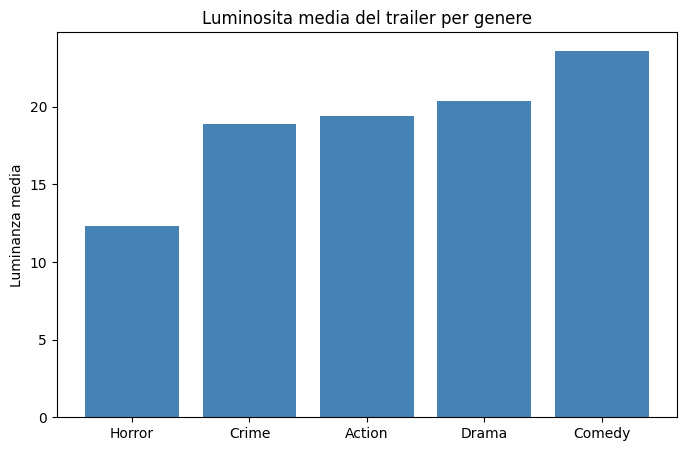

In [ ]:
import matplotlib.pyplot as plt

# Ordiniamo i generi dal piu scuro al piu chiaro
dati = media_per_genere.sort_values()

# Grafico a barre
plt.figure(figsize=(8, 5))
plt.bar(dati.index, dati.values, color="steelblue")
plt.ylabel("Luminanza media")
plt.title("Luminosita media del trailer per genere")
plt.show()

In [ ]:
# Salviamo la tabella con le misure di colore + genere
colori_df.to_csv("../data/processed/color_features.csv", index=False)
print("Salvato:", len(colori_df), "film")

Salvato: 133 film


In [ ]:
plt.savefig("../outputs/brightness_by_genre.png", dpi=100, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [ ]:
# temperatura media per genere (piu bassa = piu fredda, piu alta = piu calda)
temp_per_genere = colori_df.groupby("genere_principale")["temperature_media"].mean()
print("Temperatura media per genere (piu bassa = piu fredda):")
print(temp_per_genere.sort_values())

Temperatura media per genere (piu bassa = piu fredda):
genere_principale
Horror    1.993415
Action    2.361827
Comedy    3.417414
Drama     3.698814
Crime     3.808459
Name: temperature_media, dtype: float64


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
# le 4 misure di colore che usiamo per indovinare
colonne_colore = ["brightness_media", "brightness_std", "temperature_media", "temperature_std"]
X = colori_df[colonne_colore]   # i dati di colore (le "domande")
y = colori_df["genere_principale"]   # il genere (la "risposta giusta")
print("Righe:", len(X))
print("Generi:", y.unique())

Righe: 133
Generi: ['Action' 'Horror' 'Crime' 'Comedy' 'Drama']


In [ ]:
# dividiamo i film: una parte per imparare, una per testare
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print("Film per imparare:", len(X_train))
print("Film per testare:", len(X_test))

# creiamo il modello e lo facciamo imparare
modello = RandomForestClassifier(random_state=42)
modello.fit(X_train, y_train)

print("Modello addestrato!")

Film per imparare: 99
Film per testare: 34
Modello addestrato!


In [ ]:
# il modello indovina il genere dei 34 film di test
previsioni = modello.predict(X_test)

# quanto spesso ha indovinato?
accuratezza = accuracy_score(y_test, previsioni)
print("Accuratezza:", round(accuratezza * 100, 1), "%")

# per confronto: indovinando a caso con 5 generi si farebbe il 20%
print("Caso (indovinare a caso):", round(100/5, 1), "%")

Accuratezza: 52.9 %
Caso (indovinare a caso): 20.0 %


In [ ]:
# quanto ogni feature è stata utile al modello
importanze = modello.feature_importances_

# le abbiniamo ai nomi delle colonne e le ordiniamo
for nome, valore in zip(colonne_colore, importanze):
    print(nome, ":", round(valore, 3))

brightness_media : 0.291
brightness_std : 0.23
temperature_media : 0.218
temperature_std : 0.261


In [ ]:
from sklearn.metrics import confusion_matrix
import pandas as pd

# quali generi vengono confusi con quali
generi = sorted(y.unique())
matrice = confusion_matrix(y_test, previsioni, labels=generi)

# la mettiamo in una tabella leggibile
tabella = pd.DataFrame(matrice, index=generi, columns=generi)
print("Righe = genere vero, Colonne = genere indovinato")
print(tabella)

Righe = genere vero, Colonne = genere indovinato
        Action  Comedy  Crime  Drama  Horror
Action      14       0      0      0       1
Comedy       2       0      1      0       0
Crime        6       0      1      0       0
Drama        3       0      0      0       0
Horror       3       0      0      0       3


In [ ]:
# stesso modello, ma con i generi bilanciati (class_weight)
modello_bil = RandomForestClassifier(random_state=42, class_weight="balanced")
modello_bil.fit(X_train, y_train)

# testiamo di nuovo sui 34 film di test
previsioni_bil = modello_bil.predict(X_test)
accuratezza_bil = accuracy_score(y_test, previsioni_bil)

print("Accuratezza bilanciata:", round(accuratezza_bil * 100, 1), "%")
print("(prima era 52.9%)")

Accuratezza bilanciata: 47.1 %
(prima era 52.9%)


In [ ]:
# confusion matrix del modello bilanciato
matrice_bil = confusion_matrix(y_test, previsioni_bil, labels=generi)
tabella_bil = pd.DataFrame(matrice_bil, index=generi, columns=generi)
print("Modello bilanciato — Righe = vero, Colonne = indovinato")
print(tabella_bil)

Modello bilanciato — Righe = vero, Colonne = indovinato
        Action  Comedy  Crime  Drama  Horror
Action      13       0      0      0       2
Comedy       2       0      1      0       0
Crime        7       0      0      0       0
Drama        3       0      0      0       0
Horror       3       0      0      0       3


In [4]:
import numpy as np

# ri-processiamo i trailer, ora anche con la saturazione
risultati = []
fatti = 0

for nome_file in trailer_scaricati:
    tconst = nome_file.replace(".mp4", "")
    percorso = "../data/raw/trailers/" + nome_file

    # ora curve_from_frames restituisce QUATTRO liste
    frames = extract_frames(percorso, per_second=1)
    brightness, temperature, saturation, colours = curve_from_frames(frames)

    riga = {
        "tconst": tconst,
        "brightness_media": np.mean(brightness),
        "brightness_std": np.std(brightness),
        "temperature_media": np.mean(temperature),
        "temperature_std": np.std(temperature),
        "saturation_media": np.mean(saturation),
        "saturation_std": np.std(saturation),
        "n_frames": len(frames),
    }
    risultati.append(riga)

    fatti = fatti + 1
    if fatti % 20 == 0:
        print("Elaborati", fatti, "trailer...")

print("Finito! Trailer elaborati:", len(risultati))

Elaborati 20 trailer...
Elaborati 40 trailer...
Elaborati 60 trailer...
Elaborati 80 trailer...
Elaborati 100 trailer...
Elaborati 120 trailer...
Finito! Trailer elaborati: 133


In [3]:
import inspect
from src.metrics import curve_from_frames
print(inspect.getsource(curve_from_frames))

def curve_from_frames(frames):
    """Applica frame_metrics a tutti i frame e restituisce quattro liste."""
    brightness, temperature, saturation, colours = [], [], [], []
    for f in frames:
        m = frame_metrics(f)
        brightness.append(m["brightness"])
        temperature.append(m["temperature"])
        saturation.append(m["saturation"])
        colours.append(m["mean_colour"])
    return brightness, temperature, saturation, colours



In [5]:
# tabella aggiornata con le 6 feature
colori_df = pd.DataFrame(risultati)

colonne_utili = films[["tconst", "primaryTitle", "genere_principale", "startYear"]]
colori_df = colori_df.merge(colonne_utili, on="tconst")

print("Righe:", len(colori_df))
colori_df.head()

Righe: 133


,tconst,brightness_media,brightness_std,temperature_media,temperature_std,saturation_media,saturation_std,n_frames,primaryTitle,genere_principale,startYear
0,tt0381061,21.096695,10.851015,1.919440,6.490429,0.178188,0.129696,155,Casino Royale,Action,2006
1,tt0074285,19.384924,12.648849,6.694335,11.761136,0.487976,0.223257,127,Carrie,Horror,1976
2,tt0948470,11.445924,8.660381,-0.823597,8.654259,0.389150,0.181291,162,The Amazing Spider-Man,Action,2012
3,tt1631867,17.591673,11.684464,4.139038,6.736695,0.319060,0.169348,157,Edge of Tomorrow,Action,2014
4,tt0375679,18.845243,14.084286,3.997681,4.674487,0.332588,0.099343,148,Crash,Crime,2004


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# ora usiamo 6 feature: le 4 di prima + le 2 di saturazione
colonne_colore = [
    "brightness_media", "brightness_std",
    "temperature_media", "temperature_std",
    "saturation_media", "saturation_std",
]

X = colori_df[colonne_colore]
y = colori_df["genere_principale"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

modello = RandomForestClassifier(random_state=42, class_weight="balanced")
modello.fit(X_train, y_train)

previsioni = modello.predict(X_test)
accuratezza = accuracy_score(y_test, previsioni)

print("Accuratezza con saturazione (6 feature):", round(accuratezza * 100, 1), "%")
print("(prima con 4 feature bilanciato: 47.1%)")

Accuratezza con saturazione (6 feature): 55.9 %
(prima con 4 feature bilanciato: 47.1%)


In [8]:
from sklearn.metrics import confusion_matrix

generi = sorted(y.unique())
matrice = confusion_matrix(y_test, previsioni, labels=generi)
tabella = pd.DataFrame(matrice, index=generi, columns=generi)
print("6 feature — Righe = vero, Colonne = indovinato")
print(tabella)

6 feature — Righe = vero, Colonne = indovinato
        Action  Comedy  Crime  Drama  Horror
Action      15       0      0      0       0
Comedy       2       0      1      0       0
Crime        6       1      0      0       0
Drama        3       0      0      0       0
Horror       2       0      0      0       4


In [9]:
# Barcode starting point: controlliamo cosa contiene colori_df
print(colori_df.columns.tolist())

['tconst', 'brightness_media', 'brightness_std', 'temperature_media', 'temperature_std', 'saturation_media', 'saturation_std', 'n_frames', 'primaryTitle', 'genere_principale', 'startYear']


In [10]:
import numpy as np

# per ogni trailer teniamo la sequenza di colori (il suo barcode)
barcode_per_film = {}   # dizionario: tconst -> lista di colori

fatti = 0
for nome_file in trailer_scaricati:
    tconst = nome_file.replace(".mp4", "")
    percorso = "../data/raw/trailers/" + nome_file

    frames = extract_frames(percorso, per_second=1)
    brightness, temperature, saturation, colours = curve_from_frames(frames)

    # salviamo la sequenza di colori di questo film
    barcode_per_film[tconst] = colours

    fatti = fatti + 1
    if fatti % 20 == 0:
        print("Fatti", fatti, "trailer...")

print("Finito! Barcode raccolti:", len(barcode_per_film))

Fatti 20 trailer...
Fatti 40 trailer...
Fatti 60 trailer...
Fatti 80 trailer...
Fatti 100 trailer...
Fatti 120 trailer...
Finito! Barcode raccolti: 133


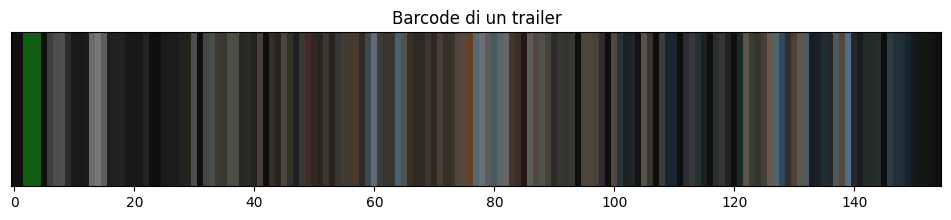

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# prendiamo un film qualsiasi
un_tconst = list(barcode_per_film.keys())[0]
colori = barcode_per_film[un_tconst]

# trasformiamo la lista di colori in una striscia disegnabile
striscia = np.array(colori).reshape(1, len(colori), 3)

plt.figure(figsize=(12, 2))
plt.imshow(striscia, aspect="auto")
plt.title("Barcode di un trailer")
plt.yticks([])
plt.show()

In [12]:
import numpy as np

# funzione che porta ogni barcode a lunghezza fissa (100 colori)
def normalizza_lunghezza(colori, n_punti=100):
    colori = np.array(colori)
    indici_originali = np.linspace(0, len(colori) - 1, len(colori))
    indici_nuovi = np.linspace(0, len(colori) - 1, n_punti)
    # interpoliamo ogni canale colore (R, G, B) separatamente
    risultato = np.zeros((n_punti, 3))
    for canale in range(3):
        risultato[:, canale] = np.interp(indici_nuovi, indici_originali, colori[:, canale])
    return risultato

# calcoliamo il barcode medio di ogni genere
generi = ["Horror", "Crime", "Action", "Drama", "Comedy"]
barcode_medi = {}

for genere in generi:
    # tconst dei film di questo genere che abbiamo scaricato
    film_genere = colori_df[colori_df["genere_principale"] == genere]["tconst"].tolist()

    strisce = []
    for tconst in film_genere:
        if tconst in barcode_per_film:
            striscia_norm = normalizza_lunghezza(barcode_per_film[tconst])
            strisce.append(striscia_norm)

    # media di tutte le strisce del genere
    barcode_medi[genere] = np.mean(strisce, axis=0)

print("Barcode medi calcolati per:", list(barcode_medi.keys()))

Barcode medi calcolati per: ['Horror', 'Crime', 'Action', 'Drama', 'Comedy']


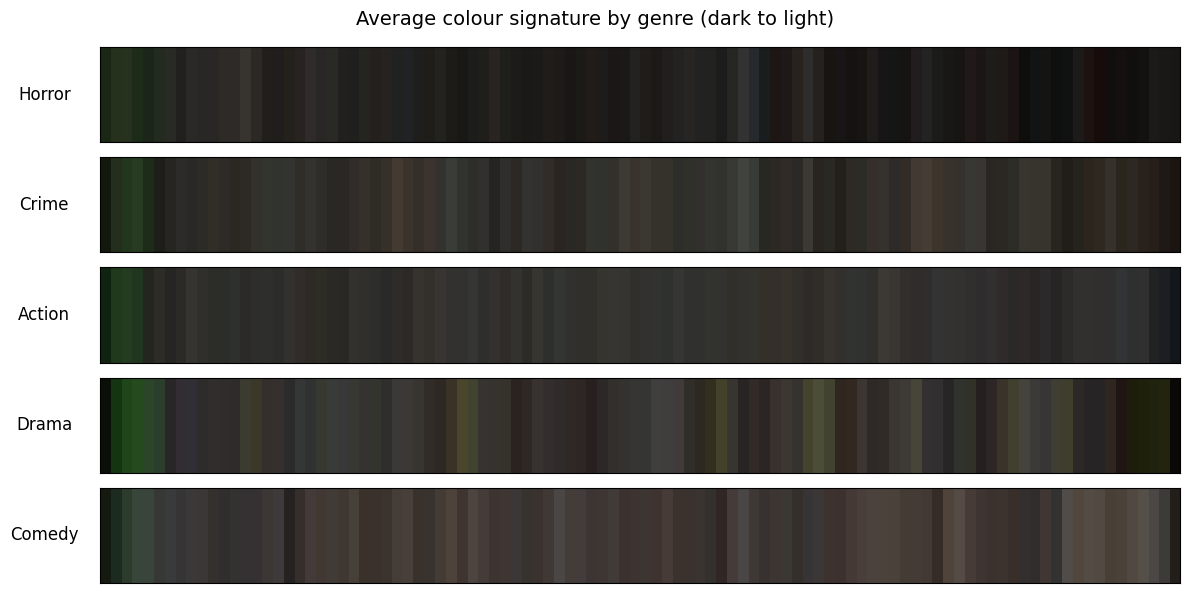

In [13]:
import matplotlib.pyplot as plt

# ordiniamo dal piu scuro al piu chiaro (come il risultato sulla luminanza)
ordine = ["Horror", "Crime", "Action", "Drama", "Comedy"]

fig, axes = plt.subplots(len(ordine), 1, figsize=(12, 6))

for i, genere in enumerate(ordine):
    striscia = barcode_medi[genere]
    # trasformiamo in immagine disegnabile
    immagine = striscia.reshape(1, len(striscia), 3)
    axes[i].imshow(immagine, aspect="auto")
    axes[i].set_yticks([])
    axes[i].set_xticks([])
    axes[i].set_ylabel(genere, rotation=0, labelpad=40, va="center", fontsize=12)

plt.suptitle("Average colour signature by genre (dark to light)", fontsize=14)
plt.tight_layout()
plt.savefig("../outputs/barcode_by_genre.png", dpi=120, bbox_inches="tight")
plt.show()

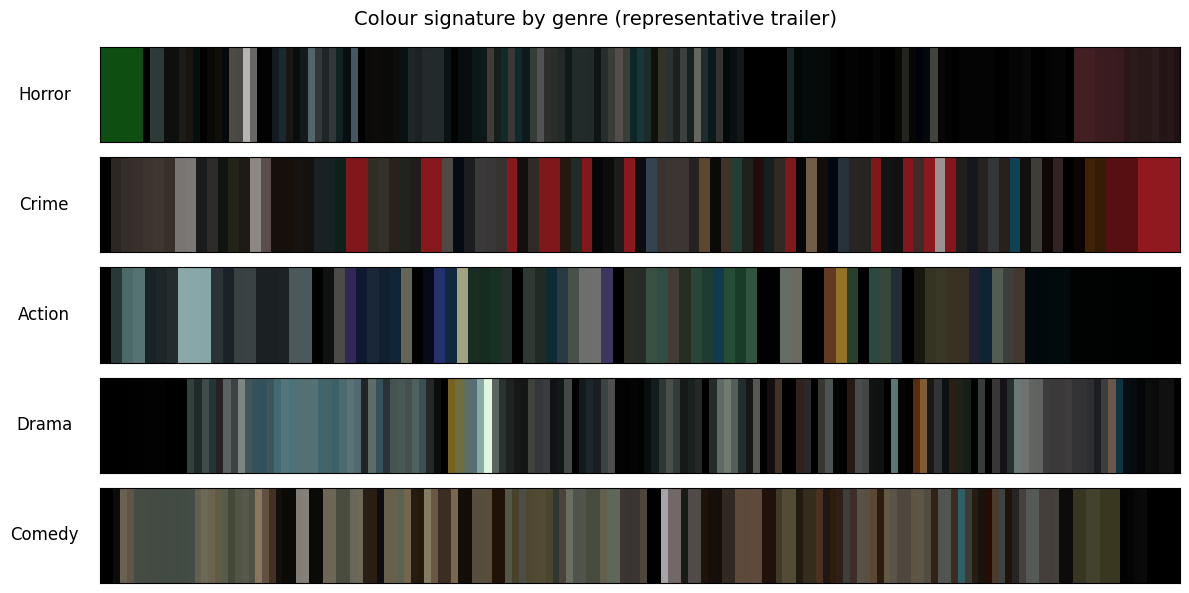

In [14]:
import matplotlib.pyplot as plt
import numpy as np

ordine = ["Horror", "Crime", "Action", "Drama", "Comedy"]
film_esemplari = {}

# per ogni genere, scegliamo il film piu vicino alla luminanza media del genere
for genere in ordine:
    gruppo = colori_df[colori_df["genere_principale"] == genere]
    media_genere = gruppo["brightness_media"].mean()

    # differenza tra ogni film e la media del suo genere
    gruppo = gruppo.copy()
    gruppo["distanza"] = (gruppo["brightness_media"] - media_genere).abs()

    # il film piu vicino alla media
    esemplare = gruppo.sort_values("distanza").iloc[0]
    film_esemplari[genere] = esemplare["tconst"]

# disegniamo il barcode vero di ogni film esemplare
fig, axes = plt.subplots(len(ordine), 1, figsize=(12, 6))

for i, genere in enumerate(ordine):
    tconst = film_esemplari[genere]
    colori = barcode_per_film[tconst]
    immagine = np.array(colori).reshape(1, len(colori), 3)

    axes[i].imshow(immagine, aspect="auto")
    axes[i].set_yticks([])
    axes[i].set_xticks([])
    axes[i].set_ylabel(genere, rotation=0, labelpad=40, va="center", fontsize=12)

plt.suptitle("Colour signature by genre (representative trailer)", fontsize=14)
plt.tight_layout()
plt.savefig("../outputs/barcode_representative.png", dpi=120, bbox_inches="tight")
plt.show()

In [2]:
import sys
sys.path.append("..")
import os
import numpy as np
import pandas as pd
from src.frames import extract_frames
from src.metrics import curve_from_frames

# carichiamo i film con genere e titolo
films = pd.read_csv("../data/source/film_with_trailers.csv")

# lista dei trailer scaricati
cartella = "../data/raw/trailers"
trailer_scaricati = []
for f in os.listdir(cartella):
    if f.endswith(".mp4"):
        trailer_scaricati.append(f)

print("Trailer da processare:", len(trailer_scaricati))

# processiamo ogni trailer e calcoliamo le 6 feature
risultati = []
fatti = 0
for nome_file in trailer_scaricati:
    tconst = nome_file.replace(".mp4", "")
    percorso = cartella + "/" + nome_file

    frames = extract_frames(percorso, per_second=1)
    brightness, temperature, saturation, colours = curve_from_frames(frames)

    riga = {
        "tconst": tconst,
        "brightness_media": np.mean(brightness),
        "brightness_std": np.std(brightness),
        "temperature_media": np.mean(temperature),
        "temperature_std": np.std(temperature),
        "saturation_media": np.mean(saturation),
        "saturation_std": np.std(saturation),
        "n_frames": len(frames),
    }
    risultati.append(riga)

    fatti = fatti + 1
    if fatti % 20 == 0:
        print("Fatti", fatti, "trailer...")

print("Estrazione finita!")

# trasformiamo in tabella e uniamo genere/titolo
colori_df = pd.DataFrame(risultati)
colonne_utili = films[["tconst", "primaryTitle", "genere_principale", "startYear"]]
colori_df = colori_df.merge(colonne_utili, on="tconst")

# salviamo direttamente nel warehouse
colori_df.to_csv("../data/warehouse/color_features.csv", index=False)
print("Salvato warehouse con", len(colori_df), "film e 6 feature")

Trailer da processare: 133
Fatti 20 trailer...
Fatti 40 trailer...
Fatti 60 trailer...
Fatti 80 trailer...
Fatti 100 trailer...
Fatti 120 trailer...
Estrazione finita!
Salvato warehouse con 133 film e 6 feature


In [3]:
import json

# per ogni trailer salviamo la sequenza completa di brightness e temperature
staging = []
fatti = 0

for nome_file in trailer_scaricati:
    tconst = nome_file.replace(".mp4", "")
    frames = extract_frames(cartella + "/" + nome_file, per_second=1)
    brightness, temperature, saturation, colours = curve_from_frames(frames)

    riga = {
        "tconst": tconst,
        "brightness_sequence": brightness,
        "temperature_sequence": temperature,
        "saturation_sequence": saturation,
    }
    staging.append(riga)

    fatti += 1
    if fatti % 20 == 0:
        print("Fatti", fatti, "trailer...")

# salviamo come JSON (le sequenze hanno lunghezze diverse, JSON le gestisce bene)
with open("../data/staging/color_sequences.json", "w") as f:
    json.dump(staging, f)

print("Staging salvato:", len(staging), "sequenze")

Fatti 20 trailer...
Fatti 40 trailer...
Fatti 60 trailer...
Fatti 80 trailer...
Fatti 100 trailer...
Fatti 120 trailer...
Staging salvato: 133 sequenze


In [4]:
import os
import pandas as pd
from src.frames import extract_frames
from src.metrics import color_distribution

# calcoliamo la distribuzione colori per tutti i 133 trailer dei generi
cartella_generi = "../data/raw/trailers"
trailer_generi = []
for f in os.listdir(cartella_generi):
    if f.endswith(".mp4"):
        trailer_generi.append(f)

print("Trailer da processare:", len(trailer_generi))

distribuzioni = []
fatti = 0
for nome_file in trailer_generi:
    tconst = nome_file.replace(".mp4", "")
    frames = extract_frames(cartella_generi + "/" + nome_file, per_second=1)
    dist = color_distribution(frames)

    # aggiungiamo il tconst al dizionario delle percentuali
    riga = {"tconst": tconst}
    for famiglia, perc in dist.items():
        riga[famiglia] = perc
    distribuzioni.append(riga)

    fatti += 1
    if fatti % 20 == 0:
        print("Fatti", fatti, "...")

print("Finito!")

# trasformiamo in tabella
color_dist_df = pd.DataFrame(distribuzioni)
print(color_dist_df.shape)
color_dist_df.head()

ImportError: cannot import name 'color_distribution' from 'src.metrics' (/Users/Maddalena/Documents/color-in-motion/notebooks/../src/metrics.py)

In [1]:
import sys
sys.path.append("..")
import os
import pandas as pd
from src.frames import extract_frames
from src.metrics import color_distribution

cartella_generi = "../data/raw/trailers"
trailer_generi = []
for f in os.listdir(cartella_generi):
    if f.endswith(".mp4"):
        trailer_generi.append(f)

print("Trailer da processare:", len(trailer_generi))

distribuzioni = []
fatti = 0
for nome_file in trailer_generi:
    tconst = nome_file.replace(".mp4", "")
    frames = extract_frames(cartella_generi + "/" + nome_file, per_second=1)
    dist = color_distribution(frames)
    riga = {"tconst": tconst}
    for famiglia, perc in dist.items():
        riga[famiglia] = perc
    distribuzioni.append(riga)
    fatti += 1
    if fatti % 20 == 0:
        print("Fatti", fatti, "...")

print("Finito!")
color_dist_df = pd.DataFrame(distribuzioni)
color_dist_df.head()

Trailer da processare: 133
Fatti 20 ...
Fatti 40 ...
Fatti 60 ...
Fatti 80 ...
Fatti 100 ...
Fatti 120 ...
Finito!


,tconst,red,orange,yellow,green,blue,purple,dark_neutral
0,tt0381061,0.0,0.045161,0.193548,0.193548,0.051613,0.000000,0.516129
1,tt0074285,0.0,0.062992,0.070866,0.220472,0.110236,0.047244,0.488189
2,tt0948470,0.0,0.037037,0.024691,0.086420,0.043210,0.000000,0.808642
3,tt1631867,0.0,0.044586,0.152866,0.203822,0.012739,0.000000,0.585987
4,tt0375679,0.0,0.162162,0.148649,0.141892,0.013514,0.000000,0.533784


In [2]:
# carichiamo i generi dal warehouse
warehouse = pd.read_csv("../data/warehouse/color_features.csv")
generi = warehouse[["tconst", "genere_principale"]]

# uniamo genere alle distribuzioni colori
dist_con_genere = color_dist_df.merge(generi, on="tconst")

# distribuzione media di colori per genere
famiglie = ["red", "orange", "yellow", "green", "blue", "purple", "dark_neutral"]
media_per_genere = dist_con_genere.groupby("genere_principale")[famiglie].mean()

# mostriamo in percentuale, arrotondato
print((media_per_genere * 100).round(1))

                   red  orange  yellow  green  blue  purple  dark_neutral
genere_principale                                                        
Action             0.3     8.2     7.4   16.4   9.3     0.4          58.0
Comedy             0.0     4.4    10.9   30.6  11.2     0.0          42.9
Crime              0.3     5.6     7.5   19.5   9.2     0.0          57.9
Drama              0.1     3.6     7.6   16.0  18.6     0.2          53.9
Horror             0.1     2.7     3.9    9.2   5.9     0.4          77.7


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# usiamo le 7 famiglie di colore come feature
famiglie = ["red", "orange", "yellow", "green", "blue", "purple", "dark_neutral"]

X = dist_con_genere[famiglie]
y = dist_con_genere["genere_principale"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

modello = RandomForestClassifier(random_state=42, class_weight="balanced")
modello.fit(X_train, y_train)

previsioni = modello.predict(X_test)
acc = accuracy_score(y_test, previsioni)
print("Accuratezza con distribuzione colori:", round(acc*100, 1), "%")
print("(prima con 6 feature medie: 55.9%)")

# confusion matrix
generi_ordinati = sorted(y.unique())
matrice = confusion_matrix(y_test, previsioni, labels=generi_ordinati)
print("\nRighe = vero, Colonne = predetto")
print(pd.DataFrame(matrice, index=generi_ordinati, columns=generi_ordinati))

Accuratezza con distribuzione colori: 47.1 %
(prima con 6 feature medie: 55.9%)

Righe = vero, Colonne = predetto
        Action  Comedy  Crime  Drama  Horror
Action      14       0      0      0       1
Comedy       2       1      0      0       0
Crime        6       1      0      0       0
Drama        3       0      0      0       0
Horror       4       0      0      1       1
